Beginning is the same as with corporate actions.
Only the returns with corporate actions are removed.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm

df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])

df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,A,22.453505,22.625179,22.267525,22.389128,19.891682,3815561.0
1,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,6.418382,493729600.0
2,2010-01-04,ABT,26.000362,26.177889,25.870815,26.129908,18.414783,10829095.0
3,2010-01-04,ACGL,7.978889,8.022222,7.972222,7.994444,7.601905,4813200.0
4,2010-01-04,ACN,41.520000,42.200001,41.500000,42.070000,31.492174,3650100.0
...,...,...,...,...,...,...,...,...
1689654,2025-12-30,XEL,73.989998,74.430000,73.989998,74.190002,74.190002,5420800.0
1689655,2025-12-30,XOM,121.099998,121.800003,120.629997,120.989998,120.989998,11148100.0
1689656,2025-12-30,YUM,151.679993,152.660004,151.449997,152.179993,152.179993,1158600.0
1689657,2025-12-30,ZBH,90.180000,90.919998,89.879997,90.790001,90.790001,934500.0


In [3]:
# artihmetic returns
df = df.sort_values(["Ticker", "Date"])

df["previous_adj_close"] = (
    df.groupby("Ticker")["Adj Close"]
      .shift(1)
)


df["arithmetic_return"] = (
    ( df["Adj Close"] - df["previous_adj_close"] ) / df["previous_adj_close"]
)

# remove first observation per ticker
df= df.dropna(subset=["arithmetic_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649
...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152


In [4]:
# arithmetic returns in pourcent

df["arithmetic_return_%"] = df["arithmetic_return"] * 100

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863,-1.086272
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553,-0.355304
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297,-0.129672
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325,-0.032458
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649,0.064927
...,...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506,-1.050610
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485,-0.348517
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505,0.150472
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152,-0.215210


In [5]:
# Log returns
df = df.sort_values(["Ticker", "Date"])

df["log_return"] = (
    np.log(df["Adj Close"])
    - np.log(df["previous_adj_close"])
)

# remove first observation per ticker
df= df.dropna(subset=["log_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
420,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863,-1.086272,-0.010922
840,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553,-0.355304,-0.003559
1260,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297,-0.129672,-0.001298
1680,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325,-0.032458,-0.000325
2100,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649,0.064927,0.000649
...,...,...,...,...,...,...,...,...,...,...,...,...
1687978,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506,-1.050610,-0.010562
1688398,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485,-0.348517,-0.003491
1688818,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505,0.150472,0.001504
1689238,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152,-0.215210,-0.002154


In [6]:
# I merge the corporate action dataset here.
# Then I will keep only the lines where no splits happened.

actions = pd.read_csv("data/sp500_corporate_actions.csv")


actions["Date"] = pd.to_datetime(actions["Date"])

df["Date"] = pd.to_datetime(df["Date"])


df = df.merge(
    actions,
    on=["Date", "Ticker"],
    how="left"
)

df = df[ df["Stock Splits"].fillna(0) == 0 ]


display(df)


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
0,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.675604,4186031.0,19.891682,-0.010863,-1.086272,-0.010922,NaN,NaN,NaN
1,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.605696,3243779.0,19.675604,-0.003553,-0.355304,-0.003559,NaN,NaN,NaN
2,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.580273,3095172.0,19.605696,-0.001297,-0.129672,-0.001298,NaN,NaN,NaN
3,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.573917,3733918.0,19.580273,-0.000325,-0.032458,-0.000325,NaN,NaN,NaN
4,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.586626,4781579.0,19.573917,0.000649,0.064927,0.000649,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1689234,2025-12-23,ZBRA,248.119995,250.550003,245.470001,246.759995,246.759995,526000.0,249.380005,-0.010506,-1.050610,-0.010562,NaN,NaN,NaN
1689235,2025-12-24,ZBRA,247.669998,247.669998,244.440002,245.899994,245.899994,374200.0,246.759995,-0.003485,-0.348517,-0.003491,NaN,NaN,NaN
1689236,2025-12-26,ZBRA,245.899994,246.550003,243.690002,246.270004,246.270004,622400.0,245.899994,0.001505,0.150472,0.001504,NaN,NaN,NaN
1689237,2025-12-29,ZBRA,246.070007,247.250000,241.800003,245.740005,245.740005,563900.0,246.270004,-0.002152,-0.215210,-0.002154,NaN,NaN,NaN


In [7]:
ari_r = df["arithmetic_return"]

stats_summary = pd.Series({
    "count": ari_r.count(),
    "mean": ari_r.mean(),
    "std": ari_r.std(),
    "variance": ari_r.var(),
    "min": ari_r.min(),
    "1%": ari_r.quantile(0.01),
    "5%": ari_r.quantile(0.05),
    "25%": ari_r.quantile(0.25),
    "median": ari_r.median(),
    "75%": ari_r.quantile(0.75),
    "95%": ari_r.quantile(0.95),
    "99%": ari_r.quantile(0.99),
    "max": ari_r.max(),
    "skewness": ari_r.skew(),
    "kurtosis": ari_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")

count       1689016.000000
mean              0.000689
std               0.019207
variance          0.000369
min              -0.538647
1%               -0.051702
5%               -0.027138
25%              -0.007856
median            0.000743
75%               0.009347
95%               0.027815
99%               0.053139
max               0.745933
skewness          0.125242
kurtosis         23.365386
dtype: object

In [8]:
log_r = df["log_return"]

stats_summary = pd.Series({
    "count": log_r.count(),
    "mean": log_r.mean(),
    "std": log_r.std(),
    "variance": log_r.var(),
    "min": log_r.min(),
    "1%": log_r.quantile(0.01),
    "5%": log_r.quantile(0.05),
    "25%": log_r.quantile(0.25),
    "median": log_r.median(),
    "75%": log_r.quantile(0.75),
    "95%": log_r.quantile(0.95),
    "99%": log_r.quantile(0.99),
    "max": log_r.max(),
    "skewness": log_r.skew(),
    "kurtosis": log_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")


count       1689016.000000
mean              0.000504
std               0.019257
variance          0.000371
min              -0.773593
1%               -0.053087
5%               -0.027513
25%              -0.007887
median            0.000743
75%               0.009304
95%               0.027435
99%               0.051775
max               0.557289
skewness         -0.643934
kurtosis         28.096156
dtype: object

From these stats we see that the mean and median are really close to 0. The mean being slightly lower would indicate a slight left skew, confirmed by the skewness number.
THe standard deviation is about 1.9%. Which seems ok for daily equity volatility.
The minimum and maximum are really extreem compared to this volatility. Would that indicate "Fat Tails"?
The kurtosis is really high ( largely above 3 ) which indicates that this is a leptokurtic distribution. Which would also indicate "Fat Tails"?

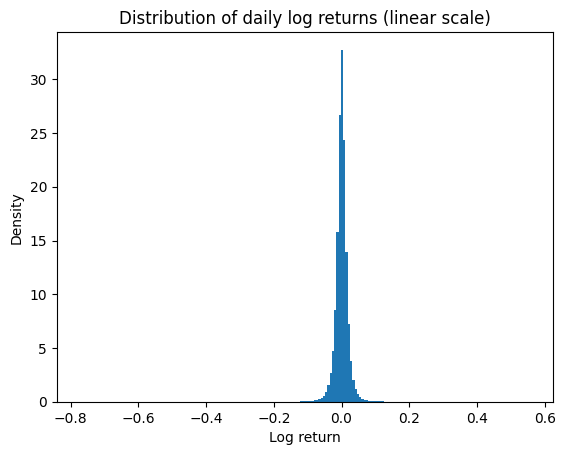

In [9]:
import matplotlib.pyplot as plt

returns = df["log_return"]

plt.hist(returns, bins=200, density=True)
plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Distribution of daily log returns (linear scale)")
plt.show()


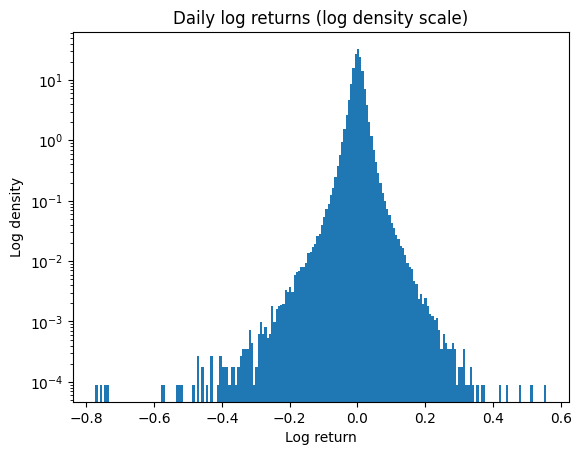

In [10]:
plt.hist(returns, bins=200, density=True)
plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Daily log returns (log density scale)")
plt.show()


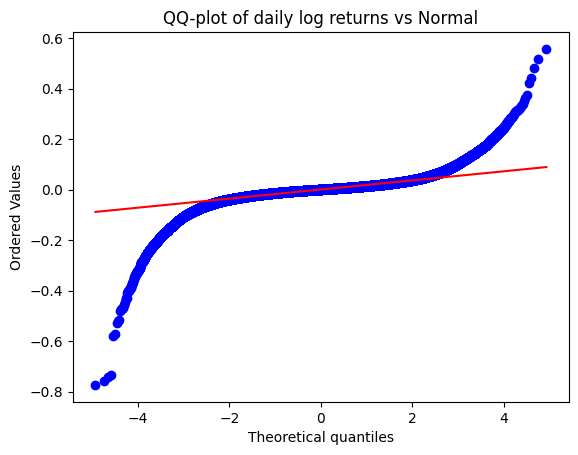

In [11]:
import scipy.stats as stats

stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot of daily log returns vs Normal")
plt.show()


We overlay with a normal to see how it fits

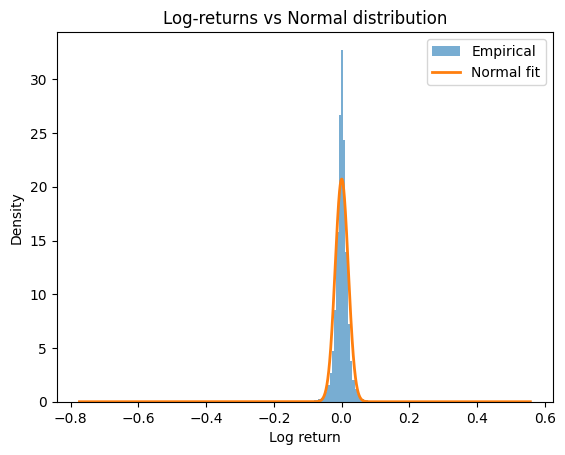

In [12]:
returns = df["log_return"].dropna()

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 2000)

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Log-returns vs Normal distribution")
plt.legend()
plt.show()

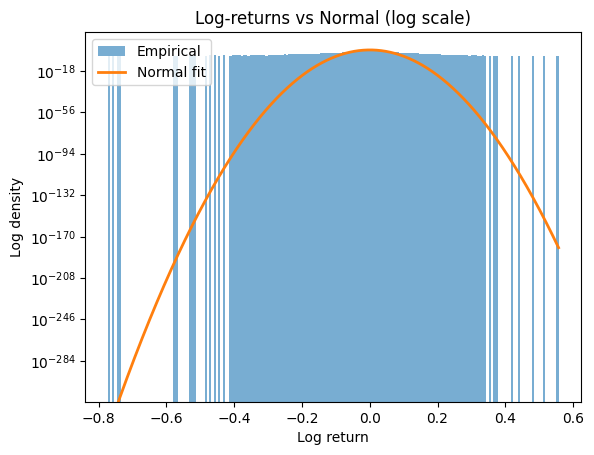

In [13]:

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Log-returns vs Normal (log scale)")
plt.legend()
plt.show()

My visualization fails because the normal is going way down in really low values... And the log scale follows

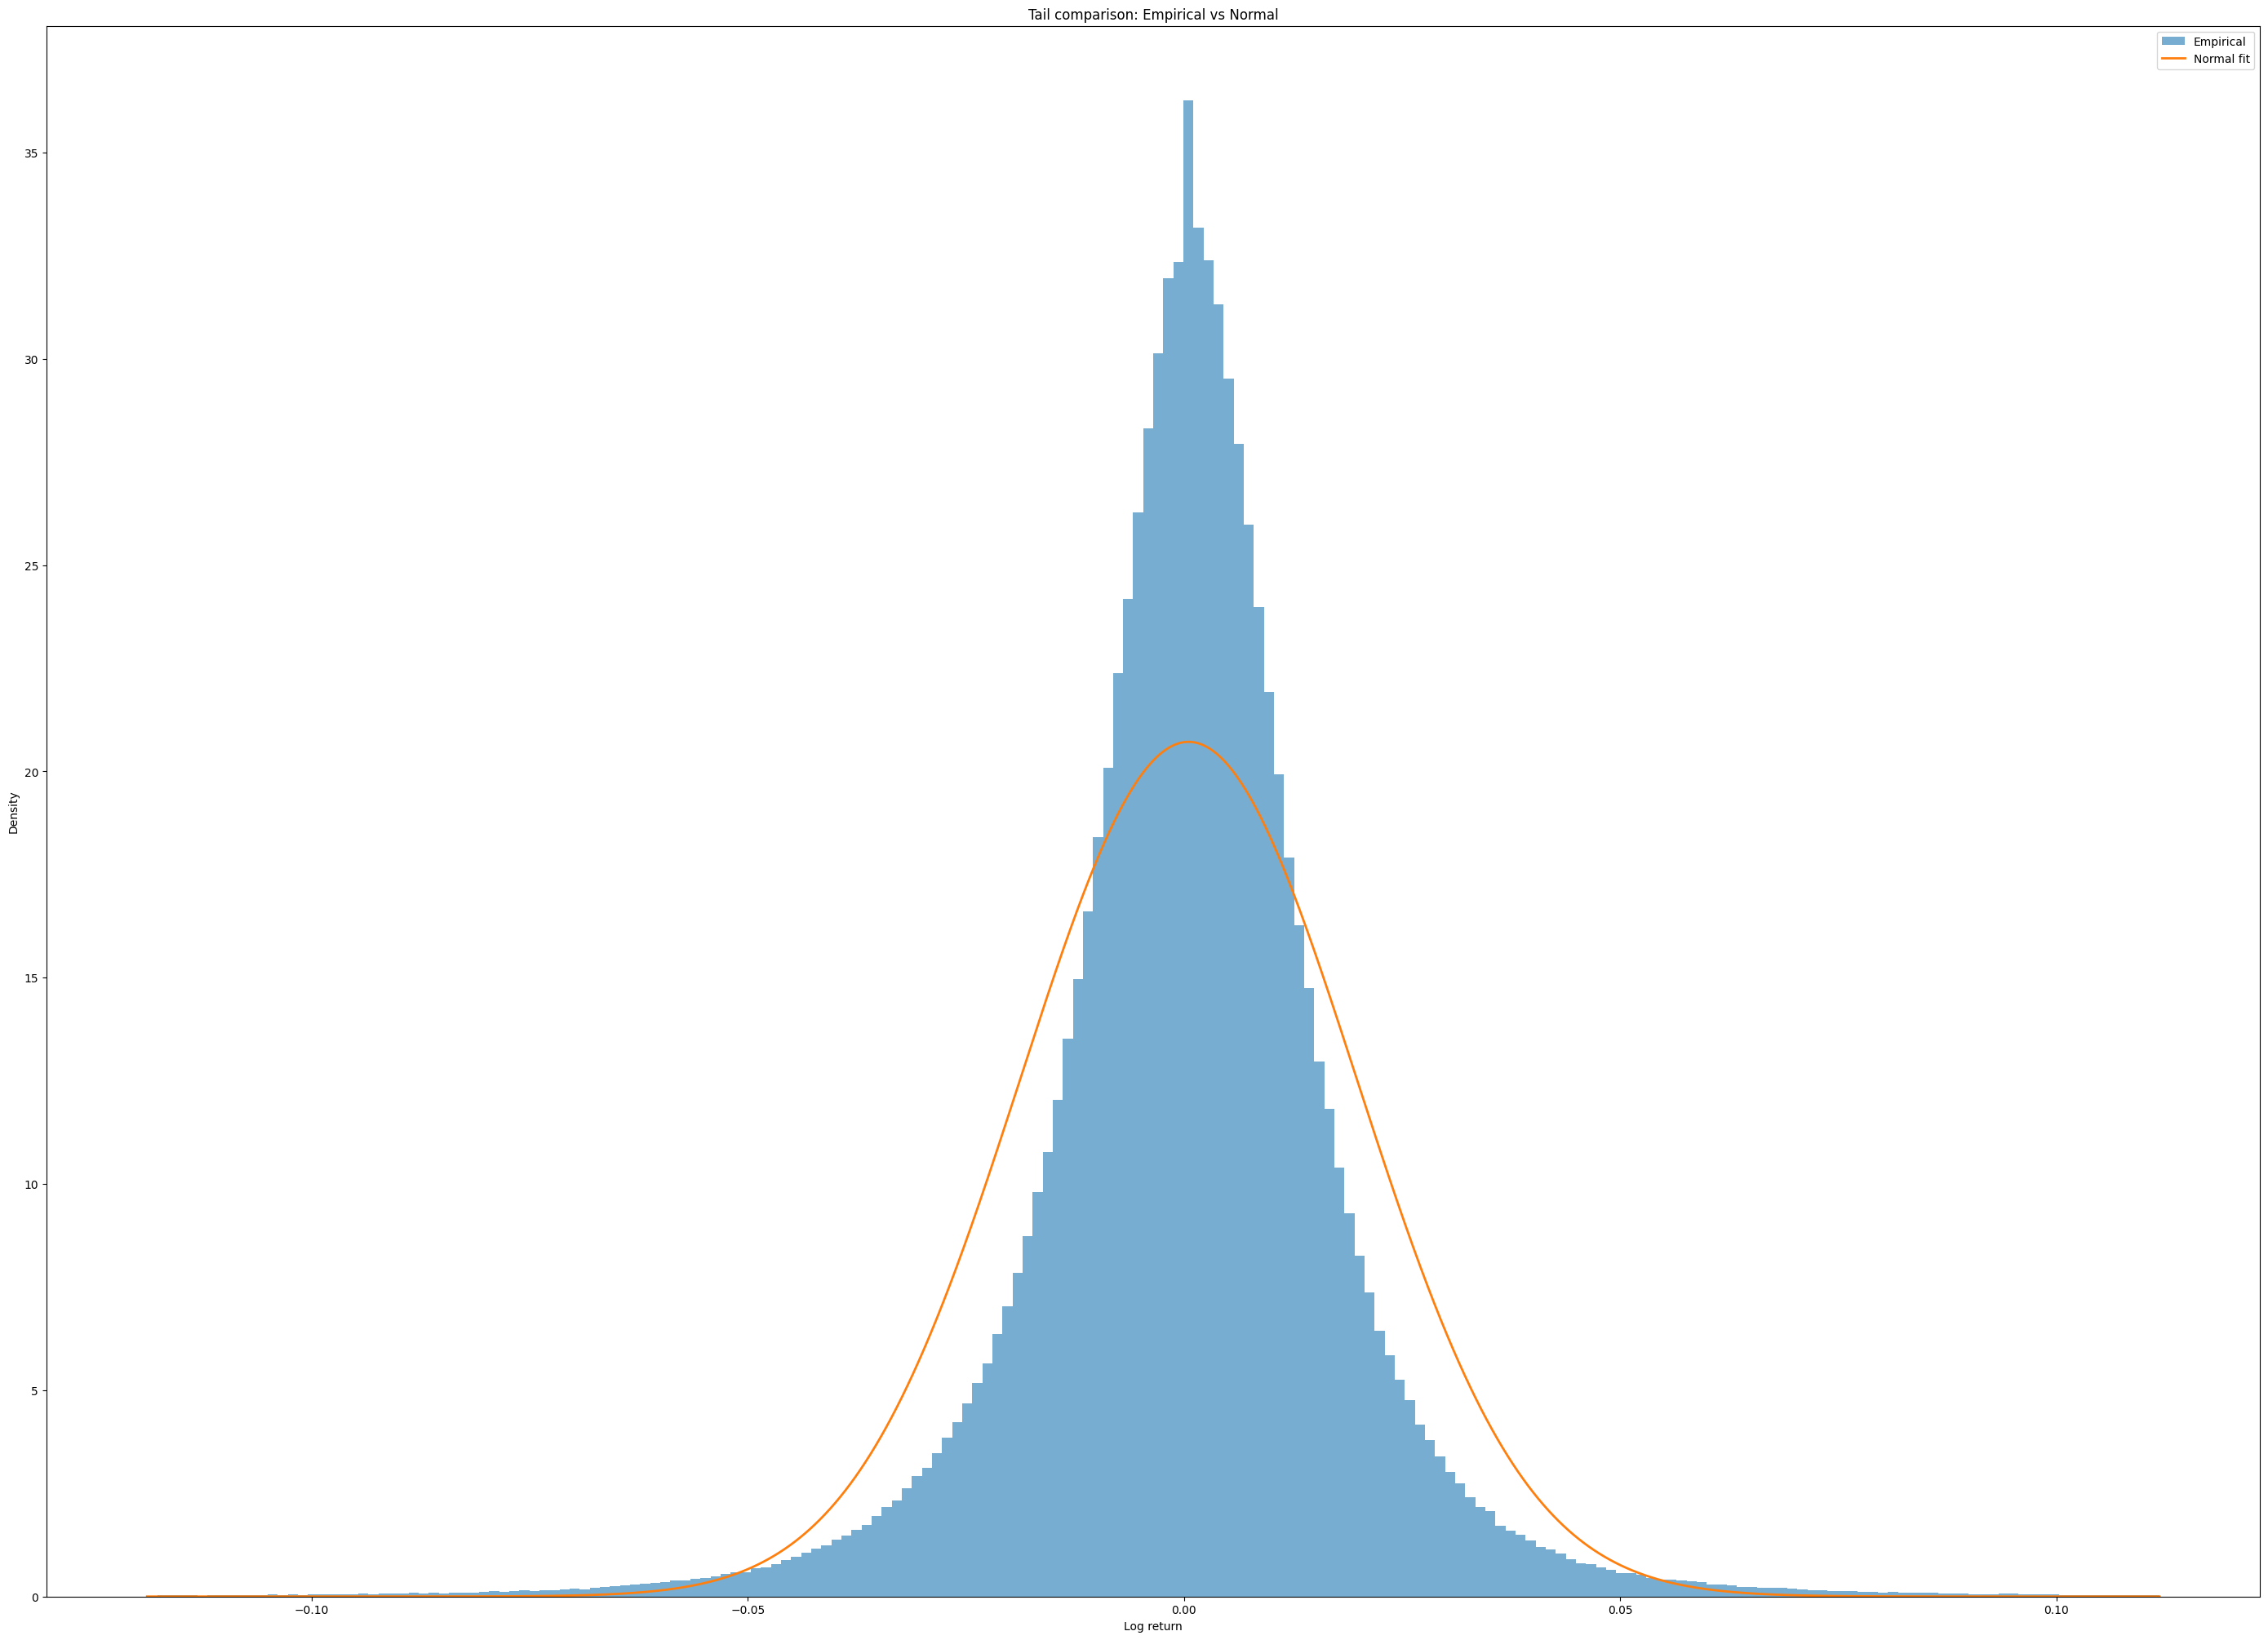

In [14]:
q_low, q_high = returns.quantile([0.001, 0.999])
q_low, q_high

x = np.linspace(q_low, q_high, 10000)
plt.figure(figsize=(35,25))
plt.hist(
    returns,
    bins=200,
    density=True,
    alpha=0.6,
    range=(q_low, q_high),
    label="Empirical"
)

plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Tail comparison: Empirical vs Normal")
plt.legend()

plt.show()

Now I will quantify the fat tails. First with Jarque-Bera and then with a simple ration of the empirical distribution over the normal.

In [15]:
from scipy.stats import jarque_bera

log_returns = df["log_return"].dropna()

jb_stat, jb_p = jarque_bera(log_returns)

print(f"JB statistic: {jb_stat:.2f}")
print(f"p-value: {jb_p:.2e}")


JB statistic: 55670508.56
p-value: 0.00e+00


In [16]:

q_emp = np.quantile(log_returns, [0.01, 0.05, 0.95, 0.99])
mu, sigma = log_returns.mean(), log_returns.std()

q_norm = norm.ppf([0.01, 0.05, 0.95, 0.99], mu, sigma)

tail_df = pd.DataFrame({
    "Empirical": q_emp,
    "Normal": q_norm,
    "Ratio": q_emp / q_norm
}, index=["1%", "5%", "95%", "99%"])

tail_df


,Empirical,Normal,Ratio
1%,-0.053087,-0.044295,1.198467
5%,-0.027513,-0.031172,0.882623
95%,0.027435,0.032179,0.852572
99%,0.051775,0.045303,1.142854


Now, I already did a skewness test (which is negative so leaning on the right with long tail on left) but I would like to now how the two tails differ.

In [17]:
# I try with the 1 percentile
q_low  = np.quantile(log_returns, 0.01)
q_high = np.quantile(log_returns, 0.99)

abs_ratio = abs(q_low) / abs(q_high)

print(q_low, q_high, abs_ratio)


-0.05308657127549492 0.05177502504308496 1.025331638783729


ratio ≈ 1 → symmetric tails

ratio > 1 → left tail heavier

ratio < 1 → right tail heavier


In [18]:
# more systematic

levels = [0.001, 0.005, 0.01, 0.05]

tail_asym = []

for p in levels:
    q_l = np.quantile(log_returns, p)
    q_u = np.quantile(log_returns, 1 - p)
    tail_asym.append({
        "p": p,
        "left": q_l,
        "right": q_u,
        "abs_ratio": abs(q_l) / abs(q_u)
    })

pd.DataFrame(tail_asym)


,p,left,right,abs_ratio
0,0.001,-0.118882,0.111816,1.063191
1,0.005,-0.067939,0.066200,1.026272
2,0.010,-0.053087,0.051775,1.025332
3,0.050,-0.027513,0.027435,1.002822


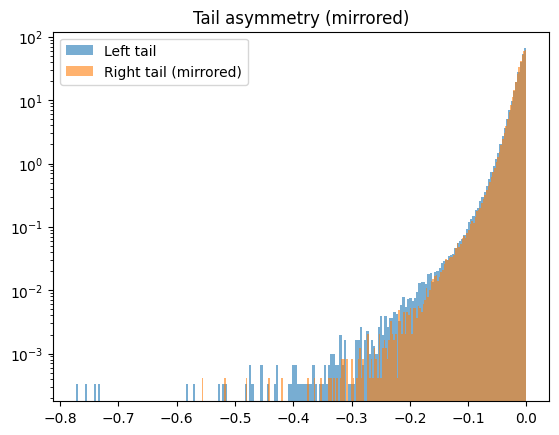

In [19]:
plt.hist(log_returns[log_returns < 0], bins=200, density=True, alpha=0.6, label="Left tail")
plt.hist(-log_returns[log_returns > 0], bins=200, density=True, alpha=0.6, label="Right tail (mirrored)")
plt.yscale("log")
plt.legend()
plt.title("Tail asymmetry (mirrored)")
plt.show()


Btw, the graph is in density mode, that's why it goes down to 10-3.

Now, I nee to check what are these outliers.

I could make a top 10 smallest returns and top 10 highest.

In [24]:
worst_10 = (
    df
    .sort_values(by="log_return", ascending=True)
    .head(10)
)

worst_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
123220,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.302564,28073200.0,17.996134,-0.538647,-53.864737,-0.773593,NaN,NaN,NaN
691351,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.506897,36577500.0,103.514908,-0.531402,-53.140182,-0.758010,NaN,NaN,NaN
1184738,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.309790,127198800.0,17.442627,-0.523593,-52.359300,-0.741483,NaN,NaN,NaN
1172961,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.763835,104930300.0,24.515041,-0.520138,-52.013807,-0.734257,34809.0,0.79,0.0
651521,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN
1473149,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.231175,40965100.0,16.324518,-0.434521,-43.452080,-0.570082,NaN,NaN,NaN
1365660,2018-10-04,SMCI,1.516000,1.516000,0.850000,1.260000,1.260000,125601000.0,2.140000,-0.411215,-41.121499,-0.529694,NaN,NaN,NaN
506413,2024-07-26,DXCM,66.000000,67.440002,62.340000,64.000000,64.000000,53914100.0,107.849998,-0.406583,-40.658321,-0.521858,NaN,NaN,NaN
345766,2025-07-02,CNC,37.340000,37.779999,33.759998,33.779999,33.779999,93566700.0,56.650002,-0.403707,-40.370701,-0.517023,NaN,NaN,NaN
1656842,2025-02-13,WST,243.839996,249.410004,197.009995,199.110001,198.591354,5219500.0,321.440521,-0.382183,-38.218320,-0.481563,NaN,NaN,NaN


In [21]:
best_10 = (
    df
    .sort_values(by="log_return", ascending=False)
    .head(10)
)

best_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
1184745,2019-01-24,PCG,7.900000,14.500000,7.300000,13.950000,13.833123,8.253830e+07,7.923057,0.745933,74.593265,0.557289,NaN,NaN,NaN
222535,2015-04-13,BLDR,11.000000,11.740000,10.500000,11.570000,11.570000,1.737750e+07,6.900000,0.676812,67.681153,0.516894,NaN,NaN,NaN
1589516,2013-04-19,VRTX,81.550003,85.900002,80.099998,85.599998,85.599998,2.489500e+07,52.869999,0.619066,61.906564,0.481849,NaN,NaN,NaN
1589278,2012-05-07,VRTX,52.119999,58.750000,51.849998,58.119999,58.119999,4.021630e+07,37.410000,0.553595,55.359527,0.440572,NaN,NaN,NaN
90069,2016-04-22,AMD,3.190000,3.990000,3.180000,3.990000,3.990000,1.432653e+08,2.620000,0.522901,52.290083,0.420617,NaN,NaN,NaN
660426,2013-04-09,FSLR,27.139999,41.000000,26.760000,39.349998,39.349998,4.017120e+07,27.040001,0.455251,45.525137,0.375179,NaN,NaN,NaN
207850,2020-11-04,BIIB,253.199997,363.920013,251.750000,355.630005,355.630005,1.459150e+07,247.009995,0.439739,43.973933,0.364462,NaN,NaN,NaN
1098773,2013-01-24,NFLX,2.057000,2.131000,1.994571,2.098000,2.098000,1.188054e+09,1.475143,0.422235,42.223507,0.352230,NaN,NaN,NaN
1589813,2014-06-24,VRTX,98.019997,98.800003,89.930000,93.529999,93.529999,2.523680e+07,66.610001,0.404143,40.414349,0.339428,NaN,NaN,NaN
208327,2022-09-28,BIIB,282.959991,283.440002,265.019989,276.609985,276.609985,1.623200e+07,197.789993,0.398503,39.850344,0.335403,NaN,NaN,NaN


In [22]:
outliers = pd.concat(
    {
        "Worst returns": worst_10,
        "Best returns": best_10
    }
)

outliers


Date Ticker        Open        High         Low  \
Worst returns 123220  2020-03-09    APA   13.420000   13.700000    9.320000   
              691351  2024-04-11     GL   98.480003   98.580002   38.950001   
              1184738 2019-01-14    PCG    9.210000    9.730000    7.780000   
              1172961 2020-03-09    OXY   15.580000   19.190001   12.040000   
              651521  2025-10-29   FISV   71.360001   76.650002   66.580002   
              1473149 2014-05-16    TKO   10.550000   11.930000   10.550000   
              1365660 2018-10-04   SMCI    1.516000    1.516000    0.850000   
              506413  2024-07-26   DXCM   66.000000   67.440002   62.340000   
              345766  2025-07-02    CNC   37.340000   37.779999   33.759998   
              1656842 2025-02-13    WST  243.839996  249.410004  197.009995   
Best returns  1184745 2019-01-24    PCG    7.900000   14.500000    7.300000   
              222535  2015-04-13   BLDR   11.000000   11.740000   10.500000   
              1589516 2013-04-19   VRTX   81.550003   85.900002   80.099998   
              1589278 2012-05-07   VRTX   52.119999   58.750000   51.849998   
              90069   2016-04-22    AMD    3.190000    3.990000    3.180000   
              660426  2013-04-09   FSLR   27.139999   41.000000   26.760000   
              207850  2020-11-04   BIIB  253.199997  363.920013  251.750000   
              1098773 2013-01-24   NFLX    2.057000    2.131000    1.994571   
              1589813 2014-06-24   VRTX   98.019997   98.800003   89.930000   
              208327  2022-09-28   BIIB  282.959991  283.440002  265.019989   

                            Close   Adj Close        Volume  \
Worst returns 123220     9.550000    8.302564  2.807320e+07   
              691351    49.169998   48.506897  3.657750e+07   
              1184738    8.380000    8.309790  1.271988e+08   
              1172961   12.510000   11.763835  1.049303e+08   
              651521    70.599998   70.599998  1.034542e+08   
              1473149   11.270000    9.231175  4.096510e+07   
              1365660    1.260000    1.260000  1.256010e+08   
              506413    64.000000   64.000000  5.391410e+07   
              345766    33.779999   33.779999  9.356670e+07   
              1656842  199.110001  198.591354  5.219500e+06   
Best returns  1184745   13.950000   13.833123  8.253830e+07   
              222535    11.570000   11.570000  1.737750e+07   
              1589516   85.599998   85.599998  2.489500e+07   
              1589278   58.119999   58.119999  4.021630e+07   
              90069      3.990000    3.990000  1.432653e+08   
              660426    39.349998   39.349998  4.017120e+07   
              207850   355.630005  355.630005  1.459150e+07   
              1098773    2.098000    2.098000  1.188054e+09   
              1589813   93.529999   93.529999  2.523680e+07   
              208327   276.609985  276.609985  1.623200e+07   

                       previous_adj_close  arithmetic_return  \
Worst returns 123220            17.996134          -0.538647   
              691351           103.514908          -0.531402   
              1184738           17.442627          -0.523593   
              1172961           24.515041          -0.520138   
              651521           126.169998          -0.440438   
              1473149           16.324518          -0.434521   
              1365660            2.140000          -0.411215   
              506413           107.849998          -0.406583   
              345766            56.650002          -0.403707   
              1656842          321.440521          -0.382183   
Best returns  1184745            7.923057           0.745933   
              222535             6.900000           0.676812   
              1589516           52.869999           0.619066   
              1589278           37.410000           0.553595   
              90069              2.620000           0.522901   
              660426

# Now I need to *try* and explain why there was these huge variation.

In [28]:
mu = df["log_return"].mean()
sigma = df["log_return"].std()

df["z_score_global"] = (df["log_return"] - mu) / sigma

In [37]:
import scipy.stats as stats

n_obs = len(df)

for k in [2, 3, 4, 5]:
    mask = df["z_score_global"].abs() > k
    
    empirical_pct = mask.mean()
    empirical_count = mask.sum()
    
    theoretical_pct = 2 * (1 - stats.norm.cdf(k))
    theoretical_count = theoretical_pct * n_obs
    
    print(f"{k}σ -> "
          f"Empirical: {empirical_pct:.6f} "
          f"({empirical_count} obs) | "
          f"Normal: {theoretical_pct:.6f} "
          f"(~{int(theoretical_count)} obs)")

2σ -> Empirical: 0.045385 (76656 obs) | Normal: 0.045500 (~76850 obs)
3σ -> Empirical: 0.015349 (25924 obs) | Normal: 0.002700 (~4559 obs)
4σ -> Empirical: 0.006755 (11409 obs) | Normal: 0.000063 (~106 obs)
5σ -> Empirical: 0.003471 (5862 obs) | Normal: 0.000001 (~0 obs)


In [39]:
# let's put a threshold at 4 sigma

# 1 Extract extreme observations
extreme_returns_std = df[df["z_score_global"].abs() > 4].copy()

print(f"Actual Number of extreme observations at 4 sigma: {len(extreme_returns_std)}")

# 2 Optional: sort for readability
extreme_returns_std = extreme_returns_std.sort_values(
    by="log_return",
    key=lambda x: x.abs(),
    ascending=False
)

# 3 Persist to CSV
extreme_returns_std.to_csv("data/sp500_sigma_extremes.csv", index=False)

Actual Number of extreme observations at 4 sigma: 11409


In [26]:
# 1️Define threshold (top 1% absolute returns)
threshold = df["log_return"].abs().quantile(0.99)

print(f"Extreme threshold (99th percentile absolute return): {threshold:.6f}")

# 2️Create extreme flag
df["extreme"] = df["log_return"].abs() >= threshold

# 3️Extract extreme observations
extreme_returns = df[df["extreme"]].copy()

print(f"Number of extreme observations: {len(extreme_returns)}")

# 4️Optional: sort for readability
extreme_returns = extreme_returns.sort_values(
    by="log_return",
    key=lambda x: x.abs(),
    ascending=False
)

# 5️Persist to CSV
extreme_returns.to_csv("data/sp500_top1pct_extremes.csv", index=False)

Extreme threshold (99th percentile absolute return): 0.067042
Number of extreme observations: 16891


In [27]:
df.count()

Date                   1689016
Ticker                 1689016
Open                   1689016
High                   1689016
Low                    1689016
Close                  1689016
Adj Close              1689016
Volume                 1689016
previous_adj_close     1689016
arithmetic_return      1689016
arithmetic_return_%    1689016
log_return             1689016
index                    21270
Dividends                21270
Stock Splits             21270
extreme                1689016
dtype: int64